# V12 XGBoost Shrub Classifier — Evaluation

Statistics and threshold-accuracy analysis for the trained `shrub_classifier_v12` model.

**Sections**
1. Load model & metadata
2. Build validation pixel dataset
3. Threshold sweep table
4. ROC curve
5. Precision-Recall curve
6. Confusion matrix
7. Feature importance
8. Threshold sweep plot
9. Summary


---
## 0. Imports

In [1]:
import json, time, warnings
import numpy as np
import pandas as pd
import joblib
import cv2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy.ndimage import uniform_filter
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, confusion_matrix,
    accuracy_score, jaccard_score,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


---
## 1. Load Model & Metadata

In [2]:
BASE        = Path(".")
META_PATH   = BASE / "v12_model_meta.json"
MODEL_PATH  = BASE / "shrub_classifier_v12.joblib"
SCALER_PATH = BASE / "shrub_scaler_v12.joblib"
VAL_JSON    = BASE / "detectron2_dataset/shrub_val_sam.json"

meta    = json.loads(META_PATH.read_text())
model   = joblib.load(MODEL_PATH)
scaler  = joblib.load(SCALER_PATH)

features       = meta["features"]
no_scale_feats = set(meta.get("no_scale_features", []))
opt_threshold  = meta["cls_threshold"]
saved_metrics  = meta["metrics"]

print(f"Model version      : {meta['version']}")
print(f"Optuna threshold   : {opt_threshold}")
print(f"Saved AUC          : {saved_metrics['auc']}")
print(f"Saved F1           : {saved_metrics['f1']}")
print(f"Top-{len(features)} features  : {features}")


Model version      : v12
Optuna threshold   : 0.5443
Saved AUC          : 0.7723
Saved F1           : 0.8229
Top-20 features  : ['canopy_height_7x7mean', 'canopy_height_5x5mean', 'naip_red_5x5std', 'brightness_7x7std', 'canopy_height_3x3mean', 'naip_red_3x3std', 'brightness_5x5std', 'canopy_height_7x7std', 'canopy_shrub_clipped', 'savi_7x7std', 'canopy_in_shrub_range', 'naip_red_7x7std', 'greenness_ratio', 'brightness_3x3mean', 'savi_7x7mean', 'naip_nir_7x7std', 'naip_green_3x3std', 'ndvi_7x7mean', 'canopy_height_5x5std', 'gndvi']


---
## 2. Build Validation Pixel Dataset

Rasterizes SAM polygon labels and extracts per-pixel features from `.npy` patches (mirrors the training pipeline exactly).

In [3]:
CHM_CHANNEL      = 4
NIR_CHANNEL      = 3
RED_CHANNEL      = 0
SHRUB_MIN_H      = 1.0
SHRUB_MAX_H      = 4.0
MAX_NEG_PER_PATCH = 200


def poly_to_mask(segmentation, H, W):
    mask = np.zeros((H, W), dtype=np.uint8)
    for poly in segmentation:
        pts = np.array(poly, dtype=np.int32).reshape(-1, 2)
        if len(pts) >= 3:
            cv2.fillPoly(mask, [pts], 1)
    return mask.astype(bool)


def extract_patch_features(img5, H, W):
    R   = img5[RED_CHANNEL].astype(np.float32)
    G   = img5[1].astype(np.float32)
    B   = img5[2].astype(np.float32)
    NIR = img5[NIR_CHANNEL].astype(np.float32)
    CHM = img5[CHM_CHANNEL].astype(np.float32)

    feats = {
        "naip_red":   R, "naip_green": G, "naip_blue":  B,
        "naip_nir":   NIR, "canopy_height": CHM,
        "ndvi":   (NIR - R)   / (NIR + R   + 1e-8),
        "savi":   1.5 * (NIR - R) / (NIR + R + 0.5 + 1e-8),
        "gndvi":  (NIR - G)   / (NIR + G   + 1e-8),
        "evi2":   2.5 * (NIR - R) / (NIR + 2.4 * R + 1.0 + 1e-8),
        "brightness":      (R + G + B + NIR) / 4.0,
        "greenness_ratio":  G / (R + G + B + 1e-8),
        "canopy_in_shrub_range": ((CHM >= SHRUB_MIN_H) & (CHM <= SHRUB_MAX_H)).astype(np.float32),
        "canopy_shrub_clipped":  np.clip(CHM, 0, SHRUB_MAX_H),
    }
    for src in ["ndvi", "naip_nir", "naip_red", "naip_green",
                "savi", "brightness", "canopy_height"]:
        arr = feats[src]
        for win in [3, 5, 7]:
            mean_v = uniform_filter(arr, size=win, mode="reflect")
            sq_m   = uniform_filter(arr ** 2, size=win, mode="reflect")
            feats[f"{src}_{win}x{win}mean"] = mean_v
            feats[f"{src}_{win}x{win}std"]  = np.sqrt(np.clip(sq_m - mean_v**2, 0, None))
    return feats


def build_pixel_rows(json_path, split_name):
    rng = np.random.default_rng(42)
    with open(json_path) as f:
        dicts = json.load(f)

    feat_names = None
    X_chunks, y_chunks, site_chunks = [], [], []
    print(f"  [{split_name}] {len(dicts)} patches — extracting features...")
    t0 = time.time()

    for d in dicts:
        anns = d.get("annotations", [])
        if not anns:
            continue
        img5 = np.nan_to_num(np.load(d["file_name"]).astype(np.float32))
        _, H, W = img5.shape
        feats = extract_patch_features(img5, H, W)
        if feat_names is None:
            feat_names = list(feats.keys())

        label_map = np.full((H, W), -1, dtype=np.int8)
        for cat_id in [1, 2, 0]:
            for ann in anns:
                if ann.get("iscrowd", 0) or ann.get("category_id", 0) != cat_id:
                    continue
                m = poly_to_mask(ann["segmentation"], H, W)
                label_map[m] = 1 if cat_id == 0 else 0

        pos_idx = np.argwhere(label_map == 1)
        neg_idx = np.argwhere(label_map == 0)
        if len(pos_idx) == 0 and len(neg_idx) == 0:
            continue
        if len(neg_idx) > MAX_NEG_PER_PATCH:
            neg_idx = neg_idx[rng.choice(len(neg_idx), MAX_NEG_PER_PATCH, replace=False)]

        idx = np.concatenate([pos_idx, neg_idx])
        ys, xs = idx[:, 0], idx[:, 1]
        labels = label_map[ys, xs].astype(np.int8)
        feat_matrix = np.stack([feats[f][ys, xs] for f in feat_names], axis=1).astype(np.float32)
        X_chunks.append(feat_matrix)
        y_chunks.append(labels)
        site_chunks.append(np.full(len(labels), d.get("site", "unknown"), dtype=object))

    X_arr = np.concatenate(X_chunks)
    y_arr  = np.concatenate(y_chunks)
    s_arr  = np.concatenate(site_chunks)
    print(f"  [{split_name}] Done in {time.time()-t0:.0f}s — "
          f"{len(y_arr):,} pixels  pos={y_arr.sum():,} ({y_arr.mean()*100:.1f}%)")
    return pd.DataFrame(X_arr, columns=feat_names), pd.Series(y_arr, dtype=int), pd.Series(s_arr)


def scale_val(X_df):
    scale_cols = [c for c in features if c not in no_scale_feats]
    X = X_df[features].copy().astype(np.float32).fillna(0.0)
    X[scale_cols] = scaler.transform(X[scale_cols].values)
    return X


X_val_raw, y_val, sites_val = build_pixel_rows(VAL_JSON, "val")
X_val = scale_val(X_val_raw)
val_proba = model.predict_proba(X_val)[:, 1]
print("Predictions ready.")


  [val] 202 patches — extracting features...


  [val] Done in 2s — 124,039 pixels  pos=83,839 (67.6%)
Predictions ready.


---
## 3. Threshold Sweep

Precision, Recall, F1, Accuracy, and IoU at every 0.05 step, plus the Optuna-selected threshold.

In [4]:
THRESHOLDS = np.round(np.arange(0.05, 1.00, 0.05), 2)

rows = []
for thr in THRESHOLDS:
    p = (val_proba >= thr).astype(int)
    rows.append({
        "Threshold": thr,
        "Precision": precision_score(y_val, p, zero_division=0),
        "Recall":    recall_score(y_val, p, zero_division=0),
        "F1":        f1_score(y_val, p, zero_division=0),
        "Accuracy":  accuracy_score(y_val, p),
        "IoU":       jaccard_score(y_val, p, zero_division=0),
    })

# Add Optuna threshold if not already in sweep
if opt_threshold not in THRESHOLDS:
    p = (val_proba >= opt_threshold).astype(int)
    rows.append({
        "Threshold": opt_threshold,
        "Precision": precision_score(y_val, p, zero_division=0),
        "Recall":    recall_score(y_val, p, zero_division=0),
        "F1":        f1_score(y_val, p, zero_division=0),
        "Accuracy":  accuracy_score(y_val, p),
        "IoU":       jaccard_score(y_val, p, zero_division=0),
    })

sweep_df = pd.DataFrame(rows).sort_values("Threshold").reset_index(drop=True)

# Styled display
best_f1_thr = sweep_df.loc[sweep_df["F1"].idxmax(), "Threshold"]

def highlight_rows(row):
    is_optuna = abs(row["Threshold"] - opt_threshold) < 0.001
    is_best   = abs(row["Threshold"] - best_f1_thr) < 0.001
    if is_optuna:
        return ["background-color: #fff3cd"] * len(row)   # yellow — Optuna
    elif is_best:
        return ["background-color: #d4edda"] * len(row)   # green  — best F1
    return [""] * len(row)

sweep_df.style \
    .apply(highlight_rows, axis=1) \
    .format({c: "{:.4f}" for c in sweep_df.columns}) \
    .set_caption("🟡 Optuna threshold  |  🟢 Best F1 threshold") \
    .set_table_styles([{"selector": "th", "props": [("font-weight", "bold")]}])


,Threshold,Precision,Recall,F1,Accuracy,IoU
0,0.0500,0.6759,1.0000,0.8066,0.6759,0.6759
1,0.1000,0.6759,1.0000,0.8066,0.6759,0.6759
2,0.1500,0.6759,1.0000,0.8066,0.6759,0.6759
3,0.2000,0.6799,0.9969,0.8084,0.6807,0.6785
4,0.2500,0.6876,0.9865,0.8104,0.6880,0.6812
5,0.3000,0.6962,0.9760,0.8127,0.6959,0.6845
6,0.3500,0.7055,0.9658,0.8154,0.7044,0.6883
7,0.4000,0.7173,0.9540,0.8189,0.7148,0.6934
8,0.4500,0.7294,0.9391,0.8210,0.7233,0.6964
9,0.5000,0.7419,0.9223,0.8224,0.7307,0.6983


---
## 4. ROC Curve

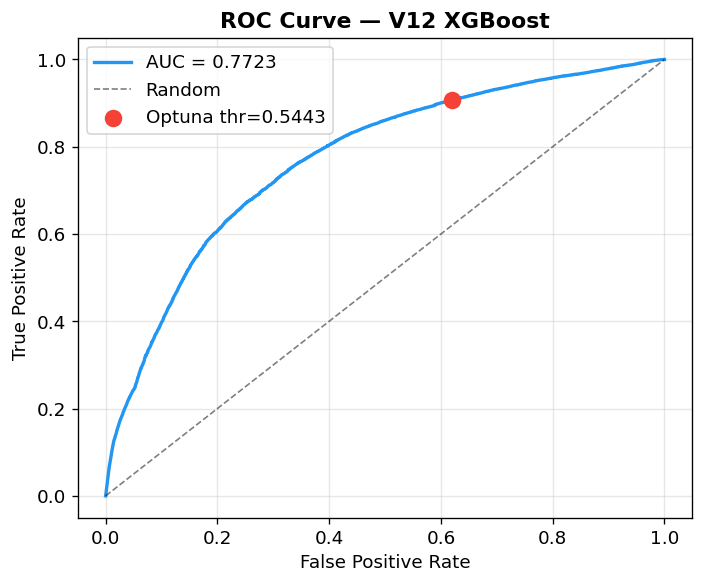

AUC-ROC: 0.7723


In [5]:
fpr, tpr, _ = roc_curve(y_val, val_proba)
auc_val = roc_auc_score(y_val, val_proba)

opt_preds = (val_proba >= opt_threshold).astype(int)
opt_fpr = (opt_preds[y_val == 0] == 1).mean()
opt_tpr = (opt_preds[y_val == 1] == 1).mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC = {auc_val:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax.scatter([opt_fpr], [opt_tpr], color="#F44336", zorder=5, s=90,
           label=f"Optuna thr={opt_threshold:.4f}")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — V12 XGBoost", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc_val:.4f}")


---
## 5. Precision-Recall Curve

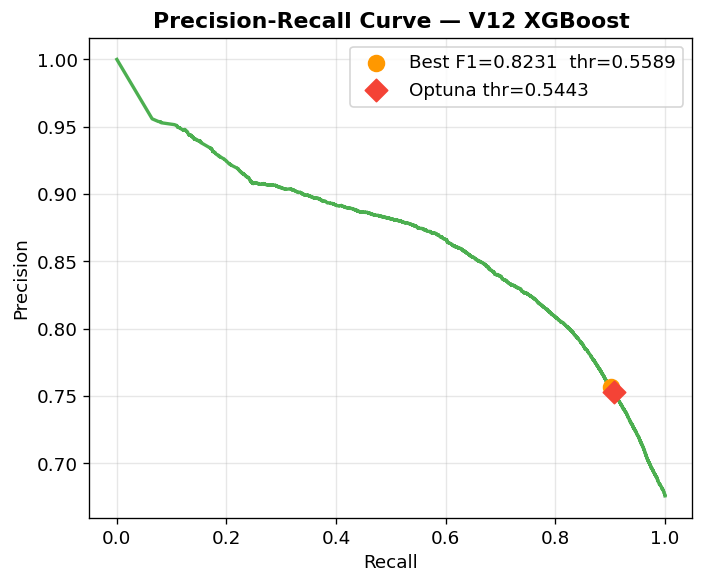

In [6]:
prec_c, rec_c, pr_thrs = precision_recall_curve(y_val, val_proba)
f1_curve = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_idx  = int(np.argmax(f1_curve))
best_pr_thr = float(pr_thrs[best_idx]) if best_idx < len(pr_thrs) else opt_threshold

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_c, prec_c, color="#4CAF50", lw=2)
ax.scatter([rec_c[best_idx]], [prec_c[best_idx]], color="#FF9800", zorder=5, s=90,
           label=f"Best F1={f1_curve[best_idx]:.4f}  thr={best_pr_thr:.4f}")
ax.scatter(
    [recall_score(y_val, opt_preds, zero_division=0)],
    [precision_score(y_val, opt_preds, zero_division=0)],
    color="#F44336", zorder=5, s=90, marker="D",
    label=f"Optuna thr={opt_threshold:.4f}"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — V12 XGBoost", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 6. Confusion Matrix

At the Optuna-selected threshold.

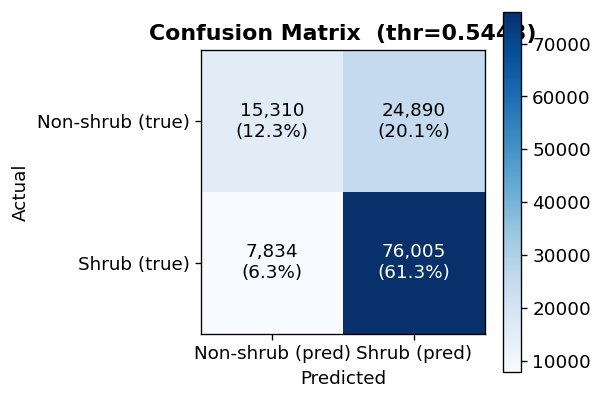

TP=76,005  FP=24,890  FN=7,834  TN=15,310


In [7]:
cm = confusion_matrix(y_val, opt_preds)
tn, fp, fn, tp = cm.ravel()
total = len(y_val)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-shrub (pred)", "Shrub (pred)"])
ax.set_yticklabels(["Non-shrub (true)", "Shrub (true)"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix  (thr={opt_threshold:.4f})", fontweight="bold")
for i in range(2):
    for j in range(2):
        v = cm[i, j]
        ax.text(j, i, f"{v:,}\n({v/total*100:.1f}%)",
                ha="center", va="center", fontsize=11,
                color="white" if v > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")


---
## 7. Feature Importance

XGBoost gain-based importance for the top-20 selected features.

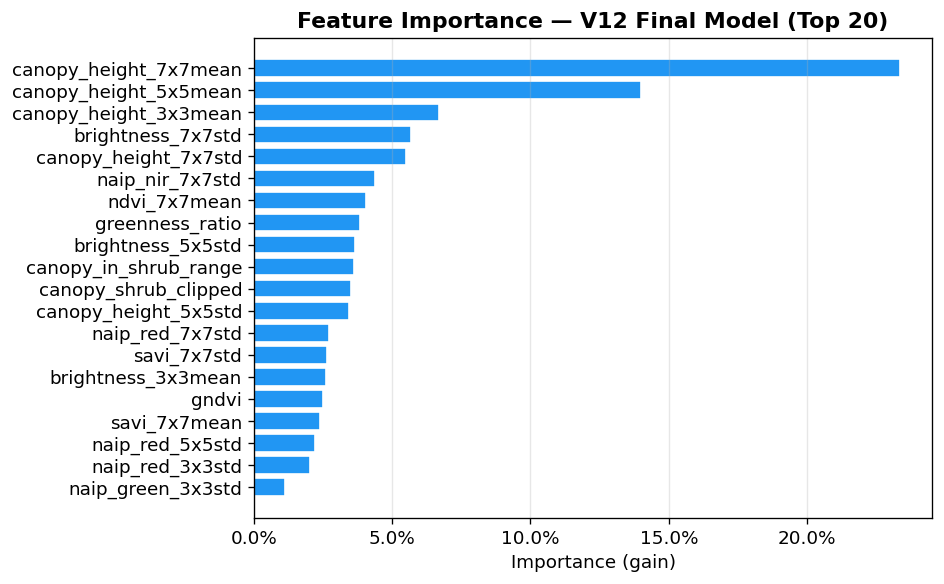

In [8]:
feat_imp = pd.DataFrame({"Feature": features, "Importance": model.feature_importances_}) \
             .sort_values("Importance")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp["Feature"], feat_imp["Importance"], color="#2196F3", edgecolor="white")
ax.set_xlabel("Importance (gain)")
ax.set_title("Feature Importance — V12 Final Model (Top 20)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8. Threshold Sweep Plot

How each metric changes as the decision threshold moves from 0 → 1.

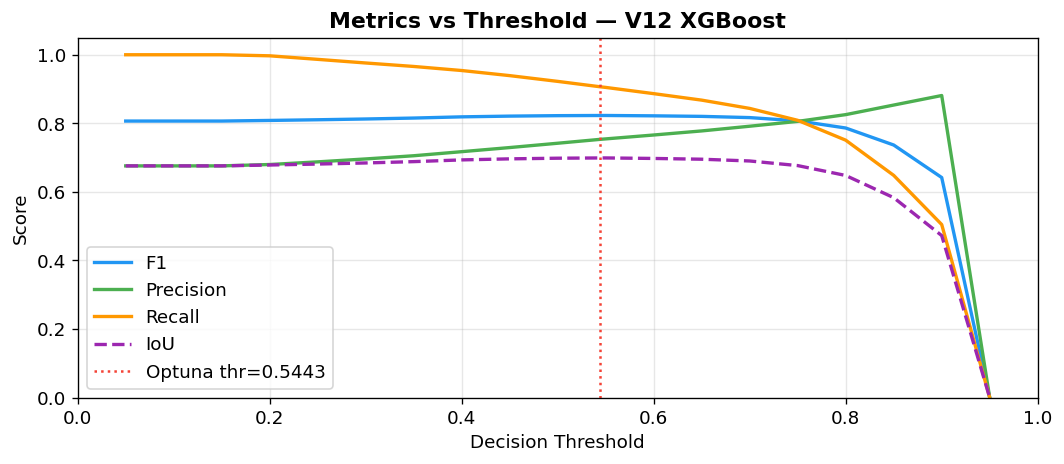

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep_df["Threshold"], sweep_df["F1"],        lw=2, label="F1",        color="#2196F3")
ax.plot(sweep_df["Threshold"], sweep_df["Precision"], lw=2, label="Precision", color="#4CAF50")
ax.plot(sweep_df["Threshold"], sweep_df["Recall"],    lw=2, label="Recall",    color="#FF9800")
ax.plot(sweep_df["Threshold"], sweep_df["IoU"],       lw=2, label="IoU",       color="#9C27B0", linestyle="--")
ax.axvline(opt_threshold, color="#F44336", linestyle=":", lw=1.5,
           label=f"Optuna thr={opt_threshold:.4f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs Threshold — V12 XGBoost", fontweight="bold")
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 9. Summary

In [10]:
p  = precision_score(y_val, opt_preds, zero_division=0)
r  = recall_score(y_val, opt_preds, zero_division=0)
f1 = f1_score(y_val, opt_preds, zero_division=0)
acc= accuracy_score(y_val, opt_preds)
iou= jaccard_score(y_val, opt_preds, zero_division=0)

summary = pd.DataFrame([
    ("Val pixels",          f"{len(y_val):,}"),
    ("Shrub pixels",        f"{y_val.sum():,} ({y_val.mean()*100:.1f}%)"),
    ("AUC-ROC",             f"{auc_val:.4f}"),
    ("Threshold (Optuna)",  f"{opt_threshold:.4f}"),
    ("Precision",           f"{p:.4f}"),
    ("Recall",              f"{r:.4f}"),
    ("F1",                  f"{f1:.4f}"),
    ("Accuracy",            f"{acc:.4f}"),
    ("IoU",                 f"{iou:.4f}"),
    ("TP / FP / FN / TN",  f"{tp:,} / {fp:,} / {fn:,} / {tn:,}"),
    ("Best PR-curve F1",    f"{f1_curve[best_idx]:.4f}  (thr={best_pr_thr:.4f})"),
], columns=["Metric", "Value"])

summary.style \
    .hide(axis="index") \
    .set_table_styles([
        {"selector": "th", "props": [("font-weight", "bold"), ("background-color", "#f0f0f0")]},
        {"selector": "td", "props": [("padding", "6px 14px")]},
    ])


Metric,Value
Val pixels,"124,039"
Shrub pixels,"83,839 (67.6%)"
AUC-ROC,0.7723
Threshold (Optuna),0.5443
Precision,0.7533
Recall,0.9066
F1,0.8229
Accuracy,0.7362
IoU,0.6990
TP / FP / FN / TN,"76,005 / 24,890 / 7,834 / 15,310"
